## 1. Encoding repair

In [3]:
import pandas as pd

DATA_PATH = r"C:\Users\Eugenia\PycharmProjects\bolttech_homework\data\claim_use_case_dataset.xlsx"
df_raw = pd.read_excel(DATA_PATH)
print(f"Rows: {df_raw.shape[0]}\nColumns: {df_raw.shape[1]}")
df_raw.head(3)

Rows: 2880
Columns: 35


,excessFee,rrp,balanceRRP,oldBalanceRRP,productName,productDesc,coverage,productCode,policyStartDate,policyEndDate,...,frontCamera,backCamera,frontOrBackCamera,audio,mic,buttons,connection,charging,other,issueDesc
0,1989.0,11990.0,11990.0,11990.0,SE_ADLD+THEFT_12M_MONTHLY_SMARTPHONE,"WUAWEI Care+ Otursskador, vÃƒÂ¤tskeskador och ...",ADLD/THEFT,SEADLDTHEFT12,2022-04-01 00:00:00,2023-04-01 00:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,***** gÃ¥ngen *** **** mobilen var nÃ¤r *** va...
1,619.0,15490.0,15490.0,15490.0,SE_MANDATORY_ADLD_12M_UPFRONT_SMARTPHONE,WUAWEI Care+ Otursskador och vÃƒÂ¤tskeskador,ADLD,SEADLD1206,28/02/2022,28/02/2023,...,1.0,1.0,NaN,1.0,1.0,0.0,NaN,NaN,NaN,*** tog telefonen frÃ¥n ***** nÃ¤r *** skulle ...
2,2509.0,19490.0,19490.0,19490.0,SE_ADLD+THEFT_12M_MONTHLY_SMARTPHONE,"WUAWEI Care+ Otursskador, vÃƒÂ¤tskeskador och ...",ADLD/THEFT,SEADLDTHEFT12,2022-04-01 00:00:00,2023-04-01 00:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*** och *** ***** var pÃ¥ semester i **** och ...


In [5]:
import ftfy

def fix_encoding(series: pd.Series) -> pd.Series:
    return series.apply(lambda x: ftfy.fix_text(x) if isinstance(x, str) else x)

df = df_raw.copy()
text_cols = df_raw.select_dtypes(include="object").columns.tolist()
text_cols = [c for c in text_cols if c not in ("policyStartDate","policyEndDate","purchaseDate")]  # dates handled separately

for c in text_cols:
    df[c] = fix_encoding(df[c])

changed = sum((df_raw[c].fillna("") != df[c].fillna("")).sum() for c in text_cols)
print(f"ftfy modified {changed} cells across {len(text_cols)} text columns")
df.head(3)

ftfy modified 1850 cells across 16 text columns


,excessFee,rrp,balanceRRP,oldBalanceRRP,productName,productDesc,coverage,productCode,policyStartDate,policyEndDate,...,frontCamera,backCamera,frontOrBackCamera,audio,mic,buttons,connection,charging,other,issueDesc
0,1989.0,11990.0,11990.0,11990.0,SE_ADLD+THEFT_12M_MONTHLY_SMARTPHONE,"WUAWEI Care+ Otursskador, vätskeskador och stöld",ADLD/THEFT,SEADLDTHEFT12,2022-04-01 00:00:00,2023-04-01 00:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,***** gången *** **** mobilen var när *** var ...
1,619.0,15490.0,15490.0,15490.0,SE_MANDATORY_ADLD_12M_UPFRONT_SMARTPHONE,WUAWEI Care+ Otursskador och vätskeskador,ADLD,SEADLD1206,28/02/2022,28/02/2023,...,1.0,1.0,NaN,1.0,1.0,0.0,NaN,NaN,NaN,*** tog telefonen från ***** när *** skulle kl...
2,2509.0,19490.0,19490.0,19490.0,SE_ADLD+THEFT_12M_MONTHLY_SMARTPHONE,"WUAWEI Care+ Otursskador, vätskeskador och stöld",ADLD/THEFT,SEADLDTHEFT12,2022-04-01 00:00:00,2023-04-01 00:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*** och *** ***** var på semester i **** och b...


## 2. Overview

Types/n_unique/n_missing, constant columns

In [8]:
info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(dropna=True),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(1),
})
info["sample_value"] = [df[c].dropna().iloc[0] for c in df.columns]
info

,dtype,n_unique,n_missing,pct_missing,sample_value
excessFee,float64,40,6,0.2,1989.0
rrp,float64,188,0,0.0,11990.0
balanceRRP,float64,352,0,0.0,11990.0
oldBalanceRRP,float64,352,0,0.0,11990.0
productName,object,134,0,0.0,SE_ADLD+THEFT_12M_MONTHLY_SMARTPHONE
productDesc,object,12,0,0.0,"WUAWEI Care+ Otursskador, vätskeskador och stöld"
coverage,object,2,0,0.0,ADLD/THEFT
productCode,object,132,3,0.1,SEADLDTHEFT12
policyStartDate,object,676,0,0.0,2022-04-01 00:00:00
policyEndDate,object,716,0,0.0,2023-04-01 00:00:00


## 2.1. Target variable

In [11]:
target = df["status"].value_counts()
target_pct = df["status"].value_counts(normalize=True).mul(100).round(1)
summary = pd.DataFrame({"count": target, "pct": target_pct}).reset_index()
summary

,status,count,pct
0,Completed,2427,84.3
1,Declined,453,15.7


15.7% decline rate → **imbalanced**.

In [14]:
df_processed = df.copy()
df_processed["target"] = (df_processed["status"] == "Declined").astype(int)
del df_processed['status']

## 2.2 Data Columns

In [17]:
date_cols = ["policyStartDate", "policyEndDate", "purchaseDate"]

for c in date_cols:
    df_processed[c] = pd.to_datetime(df[c])

date_check = pd.DataFrame({
    "n_missing": df_processed[date_cols].isna().sum(),
    "min": df_processed[date_cols].min(),
    "max": df_processed[date_cols].max(),
})
date_check

,n_missing,min,max
policyStartDate,0,2021-12-15,2024-12-07
policyEndDate,0,2022-12-15,2025-12-07
purchaseDate,0,2021-12-15,2024-12-07


Create data features and check correlations:

In [20]:
df_processed["policyDurationDays"] = (df_processed["policyEndDate"] - df_processed["policyStartDate"]).dt.days
df_processed["deviceAgeAtStartDays"] = (df_processed["policyStartDate"] - df_processed["purchaseDate"]).dt.days
new_cols = ["policyDurationDays", "deviceAgeAtStartDays"]
rows = []
for c in new_cols:
    rows.append({
        "feature": c,
        "target_corr": df_processed["target"].corr(df_processed[c])
    })
pd.DataFrame(rows)

,feature,target_corr
0,policyDurationDays,-0.032789
1,deviceAgeAtStartDays,-0.024830


**Conclusion.** Date features have low correlation with the target - drop.

In [23]:
for c in date_cols + new_cols:
    del df_processed[c]

## 2.3 Constant columns

In [26]:
const_cols = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]

rows = []
for c in const_cols:
    rows.append({
        "column": c,
        "value": df_raw[c].dropna().iloc[0],
        "present %": df[c].notna().mean(),
    })

summary = pd.DataFrame(rows)
summary.sort_values(["present %"], ascending=False)

,column,value,present %
1,deviceCost,0,1.000000
2,relationship,self,1.000000
0,make,WUAWEI,0.998958
3,smashed,0.0,0.348264
4,frontOrBackCamera,0.0,0.348264


deviceCost and relationship are constant - **to drop**. Rest - check corr.

In [29]:
dead_cols = [c for c in const_cols if df[c].notna().mean() == 1]
susp_cols = [c for c in const_cols if df[c].notna().mean() < 1]

rows = []
for c in susp_cols:
    s = df_processed[c].notna().astype(int)
    rows.append({
        "feature": c,
        "target_corr": df_processed["target"].corr(s)
    })
pd.DataFrame(rows)

,feature,target_corr
0,make,-0.045179
1,smashed,0.016488
2,frontOrBackCamera,0.016488


**Conclusion.** All constant or missing/constant with no correlation to the target - drop all.

In [32]:
for c in const_cols:
    del df_processed[c]

## 3. Missing values

In [35]:
miss = df_processed.isna().mean().mul(100).round(1)
miss_df = miss[miss > 0].sort_values(ascending=False).to_frame("pct_missing")
miss_df["sample_value"] = [df_processed[c].dropna().iloc[0] for c in miss_df.index]
miss_df

,pct_missing,sample_value
other,77.6,Het klapmechanisme is beschadigd en steekt dee...
deviceType,48.4,SMARTPHONES
connection,23.5,0.0
charging,23.5,0.0
retailerName,12.5,WUAWEI eStore
frontCamera,7.7,1.0
backCamera,7.7,1.0
audio,7.7,1.0
mic,7.7,1.0
buttons,7.7,0.0


**Colclusion**. Nothing worth manual handling: either missing text or binary blocks (likely from forms) - safe to let the model handle by default. `excessFee` is the only numerical - note for the future, neglect for now.

# 4. Feature-target correlation

## 4.1 Numericals

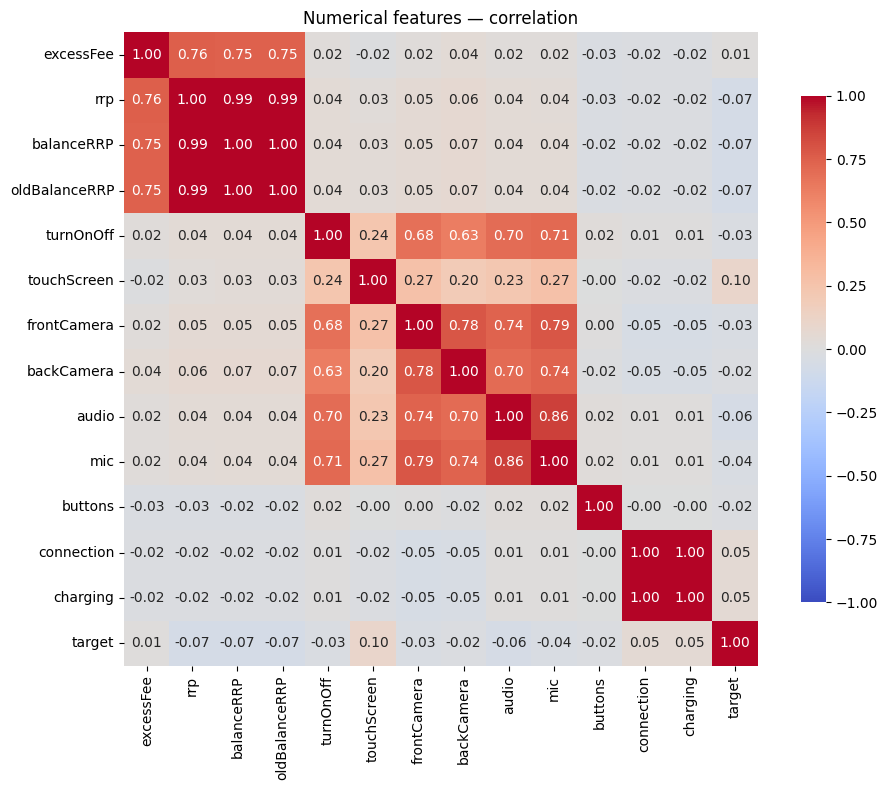

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df_processed.select_dtypes("number").columns
num_corr = df_processed[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(num_corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={"shrink": .8})
ax.set_title("Numerical features — correlation")
plt.tight_layout()
plt.show()

**Conclusion**. Almost no correlation with target (max 0.10). rrp/balanceRRP/oldBalanceRRP are multi-collinear - keep rrp, drop the rest.

In [43]:
for c in ["balanceRRP", "oldBalanceRRP"]:
    del df_processed[c]

## 4.2 Categoricals

In [46]:
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cat_cols = df_processed.select_dtypes("object").columns

cv_table = (
    pd.DataFrame({
        "feature": cat_cols,
        "cramers_v":  [cramers_v(df_processed[c], df_processed["target"]) for c in cat_cols],
        "n_categories": [df_processed[c].nunique() for c in cat_cols],
    })
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)
cv_table

,feature,cramers_v,n_categories
0,other,0.960459,607
1,issueDesc,0.956029,2798
2,model,0.426466,363
3,productCode,0.300508,132
4,productName,0.299932,134
5,deviceType,0.151819,5
6,productDesc,0.111412,12
7,retailerName,0.069795,9
8,country,0.051650,3
9,policyStatus,0.037591,3


**Conclusion**. other and issueDesc - text for NLP analysis. productDesc - can go both DT and NLP. ProductCode/productName are mostly duplicated - keep productName since productCode has some missing values.Most features are weak, coverage ~ 0. No evidence of leakage.

In [51]:
exclude_from_dt = ["other", "issueDesc"]
for c in ["productCode", "coverage"]:
    del df_processed[c]

# 5. Base Model

In [ ]:
import optuna
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Data ---
X = df_processed.drop(columns=["target"] + exclude_from_dt)
y = df_processed["target"]
cat_features = X.select_dtypes("object").columns.tolist()
X[cat_features] = X[cat_features].fillna("missing").astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

FIXED = {
    "iterations": 1000,                  # ceiling used during CV early stopping
    "auto_class_weights": "Balanced",
    "eval_metric": "AUC",
    "random_seed": 42,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def run_cv(params):
    """5-fold CV. Returns (mean AUC, mean best-iteration) for the given params."""
    aucs, best_iters = [], []
    for tr_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        m = CatBoostClassifier(**params, early_stopping_rounds=50, verbose=False)
        m.fit(Pool(X_tr, y_tr, cat_features=cat_features),
              eval_set=Pool(X_val, y_val, cat_features=cat_features))
        aucs.append(roc_auc_score(y_val, m.predict_proba(X_val)[:, 1]))
        best_iters.append(m.get_best_iteration())
    return np.mean(aucs), int(np.mean(best_iters))

def objective(trial):
    params = {
        **FIXED,
        "depth":         trial.suggest_int("depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg":   trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
    }
    mean_auc, mean_best_iter = run_cv(params)
    trial.set_user_attr("best_iter", mean_best_iter)   # stash for the final fit
    return mean_auc

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)

best_params = study.best_params
best_iter   = study.best_trial.user_attrs["best_iter"]   # CV-derived iteration count
print("Best CV AUC:", round(study.best_value, 4))
print("Best params:", best_params)
print("CV-derived iterations:", best_iter)

# --- Final model: ALL of X_train, fixed CV-derived iterations, no early stopping ---
final_params = {**FIXED, **best_params, "iterations": max(best_iter, 1)}
final_model = CatBoostClassifier(**final_params, verbose=100)
final_model.fit(Pool(X_train, y_train, cat_features=cat_features))   # full train, no eval_set

# --- Score ONCE on held-out test ---
proba = final_model.predict_proba(X_test)[:, 1]
pred  = final_model.predict(X_test)
print(f"\nTuned    — ROC-AUC: {roc_auc_score(y_test, proba):.3f}  F1: {f1_score(y_test, pred):.3f}")

  0%|          | 0/30 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.661519:   3%|▎         | 1/30 [01:21<17:19, 35.86s/it]

Best trial: 0. Best value: 0.661519:   7%|▋         | 2/30 [01:21<19:28, 41.75s/it]

Best trial: 2. Best value: 0.666827:   7%|▋         | 2/30 [01:38<19:28, 41.75s/it]

Best trial: 2. Best value: 0.666827:  10%|█         | 3/30 [01:38<13:43, 30.49s/it]

...

Best trial: 17. Best value: 0.67246:  97%|█████████▋| 29/30 [14:22<00:20, 20.28s/it]

Best trial: 17. Best value: 0.67246: 100%|██████████| 30/30 [14:22<00:00, 21.70s/it]

Best trial: 17. Best value: 0.67246: 100%|██████████| 30/30 [14:22<00:00, 28.74s/it]

Best CV AUC: 0.6725
Best params: {'depth': 4, 'learning_rate': 0.1039499544477584, 'l2_leaf_reg': 7.395487243680413}
CV-derived iterations: 98
0:	total: 33.6ms	remaining: 3.26s


97:	total: 4.13s	remaining: 0us

Tuned    — ROC-AUC: 0.636  F1: 0.308


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix

fpr, tpr, _ = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, lw=2, label=f"CatBoost (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curve")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# sklearn layout for labels [0,1]:  [[TN, FP], [FN, TP]]
tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

cm_df = pd.DataFrame(
    [[f"TN = {tn}", f"FP = {fp}"],
     [f"FN = {fn}", f"TP = {tp}"]],
    index=["Actual: Completed", "Actual: Declined"],
    columns=["Pred: Completed", "Pred: Declined"],
)
cm_df

**Conclusion**. Disappointed, but not surprised. 

In [ ]:
feature_importances = final_model.get_feature_importance()

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1])
plt.title('CatBoost Feature Importance')
plt.xlabel('Prediction Values Change')
plt.tight_layout()
plt.show()

# Embeddings

In [20]:
import os, json, hashlib
import numpy as np
import pandas as pd
import voyageai

class VoyageEmbedder():
    def __init__(self, model="voyage-4", dim=256, batch_size=128):
        self.client = voyageai.Client()          
        self.model, self.dim, self.batch_size = model, dim, batch_size

    def embed(self, texts: list[str]) -> np.ndarray:
        out = []
        for i in range(0, len(texts), self.batch_size):
            batch = texts[i:i + self.batch_size]
            resp = self.client.embed(
                batch, model=self.model,
                input_type="document",
                output_dimension=self.dim,
            )
            out.extend(resp.embeddings)
        return np.array(out, dtype=np.float32)

def embed_with_cache(texts, embedder, cache_path="issuedesc_emb_cache.json"):
    """Embed only uncached texts (keyed by hash). Reruns are free + instant."""
    cache = {}
    if os.path.exists(cache_path):
        with open(cache_path) as f:
            cache = json.load(f)
    keys = [hashlib.md5(t.encode("utf-8")).hexdigest() for t in texts]
    missing = [(t, k) for t, k in zip(texts, keys) if k not in cache]
    if missing:
        vecs = embedder.embed([t for t, _ in missing])
        for (_, k), v in zip(missing, vecs):
            cache[k] = v.tolist()
        with open(cache_path, "w") as f:
            json.dump(cache, f)
    return np.array([cache[k] for k in keys], dtype=np.float32)

In [21]:
def get_emb(col="issueDesc"):
    texts = (
        df_processed[col]
        .fillna("")
        .astype(str)
        .str.strip()
        .replace("", " ")   # empty -> single space placeholder
        .tolist()
    )
    embedder = VoyageEmbedder(model="voyage-4", dim=256)
    emb = embed_with_cache(texts, embedder)
    print("Embeddings:", emb.shape)

    emb_cols = [f"emb_{col}_{i}" for i in range(emb.shape[1])]
    emb_df = pd.DataFrame(emb, columns=emb_cols, index=df_processed.index)
    return emb_df

In [22]:
emb_df_issue = get_emb()

Embeddings: (2880, 256)


In [23]:
emb_df_other = get_emb(col="other")

Embeddings: (2880, 256)


In [ ]:
# --- Combined model: tabular + embeddings, same split + same tuned params as the tuning step above ---
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score, f1_score

X_comb = pd.concat([X, emb_df_issue, emb_df_other], axis=1)    # X = tuned tabular features
X_tr = X_comb.loc[X_train.index]
X_te = X_comb.loc[X_test.index]
# embeddings are numeric -> cat_features list is unchanged

model_text = CatBoostClassifier(**final_params, verbose=100)   # reuse tuned params + CV iters from above
model_text.fit(Pool(X_tr, y_train, cat_features=cat_features))  # full train, no early stop

proba = model_text.predict_proba(X_te)[:, 1]
pred  = model_text.predict(X_te)

print()
print(f"+ text (issueDesc + other) -> ROC-AUC: {roc_auc_score(y_test, proba):.3f}  F1: {f1_score(y_test, pred):.3f}")
print("tuned (tabular only)       -> ROC-AUC: 0.618  F1: 0.273")

In [25]:
# Per-claim: total text contribution (magnitude, not direction-by-dimension)
shap_vals = model_text.get_feature_importance(
    Pool(X_te, y_test, cat_features=cat_features), type="ShapValues"
)
# shap_vals shape: (n_rows, n_features + 1); last col is the base value
shap_df = pd.DataFrame(shap_vals[:, :-1], columns=X_tr.columns, index=X_te.index)

emb_cols = [c for c in shap_df.columns if c.startswith("emb_")]
text_contrib = shap_df[emb_cols].sum(axis=1)        # net text push per claim
tab_contrib  = shap_df.drop(columns=emb_cols)       # readable per-claim tabular SHAP

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

imp = pd.Series(model_text.get_feature_importance(), index=X_tr.columns)

emb_mask = imp.index.str.startswith("emb_")
imp_agg = pd.concat([
    imp[~emb_mask],
    pd.Series({"issueDesc (text)": imp[emb_mask].sum()}),
]).sort_values(ascending=False)

colors = ["#d1495b" if name == "issueDesc (text)" else "#4c72b0" for name in imp_agg.index]

fig, ax = plt.subplots(figsize=(8, 6))
imp_agg.plot.barh(ax=ax, color=colors)
ax.invert_yaxis()                                 
ax.set_xlabel("Importance (embedding dims summed)")
ax.set_title("Feature importance — text vs. structured features")
plt.tight_layout()
plt.show()

imp_agg.round(2)

NameError: name 'model_text' is not defined

In [ ]:
# =============================================================
# Export model + serving contract for the FastAPI app
# =============================================================
# Saves three things the app loads at startup:
#   1. catboost_model.cbm  - the trained combined model
#   2. feature_spec.json   - exact column order, cat_features, per-field embedding spec,
#                            and the preprocessing contract (must match training)
#   3. sample_claim.json   - one real claim for the happy-path test / API example

import json
from pathlib import Path

ARTIFACTS = Path("../artifacts")
ARTIFACTS.mkdir(exist_ok=True)

# --- 1. The trained model (combined: tabular + issueDesc + other embeddings) ---
model_text.save_model(str(ARTIFACTS / "catboost_model.cbm"))

# --- 2. The serving contract ---
# X_comb is the exact frame the model was trained on (tabular + emb_issueDesc_* + emb_other_*).
# Column ORDER matters: CatBoost aligns by position at inference.
tabular_cols = [c for c in X_comb.columns if not c.startswith("emb_")]

embeddings_spec = [
    {
        "name": col,
        "provider": "voyage",
        "model": "voyage-4",
        "dim": emb_df.shape[1],
        "input_type": "document",
        "column_prefix": f"emb_{col}",
        "source_column": col,
    }
    for col, emb_df in [("issueDesc", emb_df_issue), ("other", emb_df_other)]
]

feature_spec = {
    "feature_order":   list(X_comb.columns),        # full order incl. emb_*; enforce at serve
    "tabular_columns": tabular_cols,                # structured features only
    "cat_features":    cat_features,                # which tabular cols are categorical
    "embeddings":      embeddings_spec,             # one entry per embedded free-text column
    "preprocessing": {
        # Serving MUST replicate these exactly (they were applied during training):
        "dropped_columns": [e["source_column"] for e in embeddings_spec],  # embedded, not tabular
        "categorical_fillna": "missing",            # object NaN -> "missing", str-cast
        "text_columns": [e["source_column"] for e in embeddings_spec],     # embedded live at serve time
        "numeric_nan": "left_as_is",                # CatBoost handles numeric NaN natively
    },
    "target": "target",
    "positive_class_meaning": "declined",           # target==1 means the claim was declined
}

with open(ARTIFACTS / "feature_spec.json", "w") as f:
    json.dump(feature_spec, f, indent=2)

# --- 3. A sample claim (raw, pre-processing) for the API test/example ---
# Pull one real row from the ORIGINAL frame so the app sees realistic raw input.
sample_raw = df.iloc[0].drop(labels=["target"], errors="ignore").to_dict()
# json-safe (numpy types -> native)
sample_raw = {k: (v.item() if hasattr(v, "item") else v) for k, v in sample_raw.items()}
# NaN -> None: standard JSON has no NaN literal, and strict JSON clients (e.g. httpx)
# reject it outright. None round-trips identically through ClaimPredictor either way
# (categorical missing -> "missing", numeric missing -> left as NaN once back in a
# DataFrame), so this changes the wire format only, not the prediction behavior.
sample_raw = {k: (None if isinstance(v, float) and v != v else v) for k, v in sample_raw.items()}
with open(ARTIFACTS / "sample_claim.json", "w") as f:
    json.dump(sample_raw, f, indent=2, default=str)

print("Saved to artifacts/:")
print("  catboost_model.cbm  -", (ARTIFACTS / "catboost_model.cbm").stat().st_size, "bytes")
print("  feature_spec.json   -", len(feature_spec["feature_order"]), "features",
      f"({len(tabular_cols)} tabular + {sum(e['dim'] for e in embeddings_spec)} embedding)")
print("  sample_claim.json   -", len(sample_raw), "raw fields")

In [28]:
# =============================================================
# MLflow: experiment tracking, model registry, prompt registry
# =============================================================
# Local-only -- no server process, no API key. The sqlite backend supports both the
# Model Registry and the Prompt Registry (the plain file:// store does not).
import mlflow
from pathlib import Path

REPO_ROOT = Path("..").resolve()
MLFLOW_DB_PATH = REPO_ROOT / "mlflow.db"
MLRUNS_PATH = REPO_ROOT / "mlruns"

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH.as_posix()}")

EXPERIMENT_NAME = "claim-approval-catboost"
# Pin the artifact location explicitly -- otherwise mlflow defaults to "./mlruns"
# relative to the notebook's cwd (notebooks/), not the repo root. The "file:///"
# prefix matters on Windows: without it, a bare "c:/..." path gets misparsed as a
# URI with scheme "c" (the drive letter), and mlflow can't find an artifact
# repository registered for that scheme.
if mlflow.get_experiment_by_name(EXPERIMENT_NAME) is None:
    mlflow.create_experiment(EXPERIMENT_NAME, artifact_location=f"file:///{MLRUNS_PATH.as_posix()}")
mlflow.set_experiment(EXPERIMENT_NAME)

2026/06/25 09:50:00 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/06/25 09:50:00 INFO mlflow.store.db.utils: Updating database tables


<Experiment: artifact_location='file:///C:/Users/Eugenia/PycharmProjects/bolttech_homework/mlruns', creation_time=1782373803442, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1782373803442, lifecycle_stage='active', name='claim-approval-catboost', tags={}, trace_location=None, workspace='default'>

In [29]:
# --- Run 1: tabular-only baseline (for AUC-lift comparability in the MLflow UI) ---
with mlflow.start_run(run_name="tabular-baseline") as run_baseline:
    mlflow.log_params({
        "depth": best_params["depth"],
        "learning_rate": best_params["learning_rate"],
        "l2_leaf_reg": best_params["l2_leaf_reg"],
        "iterations": final_params["iterations"],
        "auto_class_weights": "Balanced",
        "cv_folds": 5,
        "optuna_trials": 30,
        "feature_set": "tabular_only",
    })
    baseline_proba = final_model.predict_proba(X_test)[:, 1]
    baseline_pred = final_model.predict(X_test)
    mlflow.log_metrics({
        "test_roc_auc": roc_auc_score(y_test, baseline_proba),
        "test_f1": f1_score(y_test, baseline_pred),
        "cv_best_auc": study.best_value,
    })
    mlflow.set_tags({"model_variant": "tabular_only", "feature_count": len(X_train.columns)})
    mlflow.catboost.log_model(final_model, artifact_path="model")
    baseline_run_id = run_baseline.info.run_id

print("Baseline run id:", baseline_run_id)

2026/06/25 09:50:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Baseline run id: 7d55eb9ca24c4eb29cf90ca04e8c3020


In [30]:
# --- Run 2: tabular + issueDesc text embeddings (the model that ships) ---
with mlflow.start_run(run_name="tabular-plus-text") as run_text:
    mlflow.log_params({
        "depth": best_params["depth"],
        "learning_rate": best_params["learning_rate"],
        "l2_leaf_reg": best_params["l2_leaf_reg"],
        "iterations": final_params["iterations"],
        "auto_class_weights": "Balanced",
        "cv_folds": 5,
        "optuna_trials": 30,
        "feature_set": "tabular_plus_issueDesc_embedding",
        "embedding_provider": "voyage",
        "embedding_model": "voyage-4",
        "embedding_dim": sum(c.startswith("emb_") for c in X_comb.columns),
    })
    text_proba = model_text.predict_proba(X_te)[:, 1]
    text_pred = model_text.predict(X_te)
    mlflow.log_metrics({
        "test_roc_auc": roc_auc_score(y_test, text_proba),
        "test_f1": f1_score(y_test, text_pred),
    })
    mlflow.set_tags({
        "model_variant": "tabular_plus_text",
        "feature_count": len(X_comb.columns),
        "linked_baseline_run_id": baseline_run_id,
    })

    model_info = mlflow.catboost.log_model(model_text, artifact_path="model")

    # Logged after the export cell above already wrote these to ../artifacts/.
    mlflow.log_artifact(str(ARTIFACTS / "feature_spec.json"), artifact_path="serving_contract")
    mlflow.log_artifact(str(ARTIFACTS / "sample_claim.json"), artifact_path="serving_contract")

    text_run_id = run_text.info.run_id

print("Text-model run id:", text_run_id)
print("Model URI:", model_info.model_uri)

2026/06/25 09:50:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Text-model run id: ac84ed9133cc4e7cadc4e8b6ccb3aacf
Model URI: models:/m-4cd734679501472ca18052352ac858b7


In [31]:
# --- Register the served model + point a 'champion' alias at the new version ---
REGISTERED_MODEL_NAME = "claim-approval-catboost"

registered_version = mlflow.register_model(
    model_uri=f"runs:/{text_run_id}/model",
    name=REGISTERED_MODEL_NAME,
)

mlflow_client = mlflow.MlflowClient()
mlflow_client.set_registered_model_alias(
    name=REGISTERED_MODEL_NAME,
    alias="champion",
    version=registered_version.version,
)

print(f"Registered {REGISTERED_MODEL_NAME} v{registered_version.version} -> alias 'champion'")

Successfully registered model 'claim-approval-catboost'.
2026/06/25 09:50:18 WARNING mlflow.tracking._model_registry.fluent: Run with id ac84ed9133cc4e7cadc4e8b6ccb3aacf has no artifacts at artifact path 'model', registering model based on models:/m-4cd734679501472ca18052352ac858b7 instead


Registered claim-approval-catboost v1 -> alias 'champion'


Created version '1' of model 'claim-approval-catboost'.


In [32]:
# --- Register both persona prompts in the MLflow Prompt Registry ---
# Pure lineage/audit versioning -- the app keeps loading + .format()-ing
# app/prompts/*.txt directly and never talks to MLflow at request time.
import sys
sys.path.insert(0, "..")
from app.config import PERSONAS

for persona, prompt_path in PERSONAS.items():
    prompt_version = mlflow.genai.register_prompt(
        name=f"claim-explainer-{persona}",
        template=prompt_path.read_text(),
        commit_message=f"Synced from app/prompts/{prompt_path.name} at run {text_run_id}",
        tags={"linked_run_id": text_run_id, "persona": persona},
    )
    print(f"claim-explainer-{persona} -> version {prompt_version.version}")

claim-explainer-customer -> version 1


claim-explainer-adjuster -> version 1


In [33]:
# --- Patch feature_spec.json with MLflow lineage now that run_id + registered ---
# --- version exist (the export cell above already wrote the file once). ---
spec_path = ARTIFACTS / "feature_spec.json"
feature_spec = json.loads(spec_path.read_text())
feature_spec["mlflow"] = {
    "tracking_uri": f"sqlite:///{MLFLOW_DB_PATH.as_posix()}",
    "run_id": text_run_id,
    "registered_model_name": REGISTERED_MODEL_NAME,
    "model_version": registered_version.version,
}
spec_path.write_text(json.dumps(feature_spec, indent=2))

print("feature_spec.json updated with mlflow lineage:", feature_spec["mlflow"])

feature_spec.json updated with mlflow lineage: {'tracking_uri': 'sqlite:///C:/Users/Eugenia/PycharmProjects/bolttech_homework/mlflow.db', 'run_id': 'ac84ed9133cc4e7cadc4e8b6ccb3aacf', 'registered_model_name': 'claim-approval-catboost', 'model_version': 1}
